# Part 4 — Luke Davis: Visualization & writeup

Load outputs from Parts 1, 2, 3

In [7]:
import re
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import statistics
import pickle

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx


## Steepest-ascent walker animation

Random starting nodes, deterministic gradient steps, walker trails

Render as animated GIF

## Final figures

Polish lattice plot and box and whisker from Part 1 to publication quality

In [17]:
with open("lookup.pkl", "rb") as f:
    lookup = pickle.load(f)

# Pick AMP+CPR+ERY+DOX+TMP at peak dose for all five drugs
focal = ["AMP", "CPR", "ERY", "DOX", "TMP"]
focal_set = frozenset(focal)
doses = {d: 3 for d in focal}

slice_nodes = []
for s in lookup:
    if not s.issubset(focal_set):
        continue
    rec = lookup[s].get(tuple(sorted((d, doses[d]) for d in s)))
    if rec is None:
        continue
    slice_nodes.append((s, rec["mean"]))
print(f"Subsets in this slice: {len(slice_nodes)}")

Subsets in this slice: 31


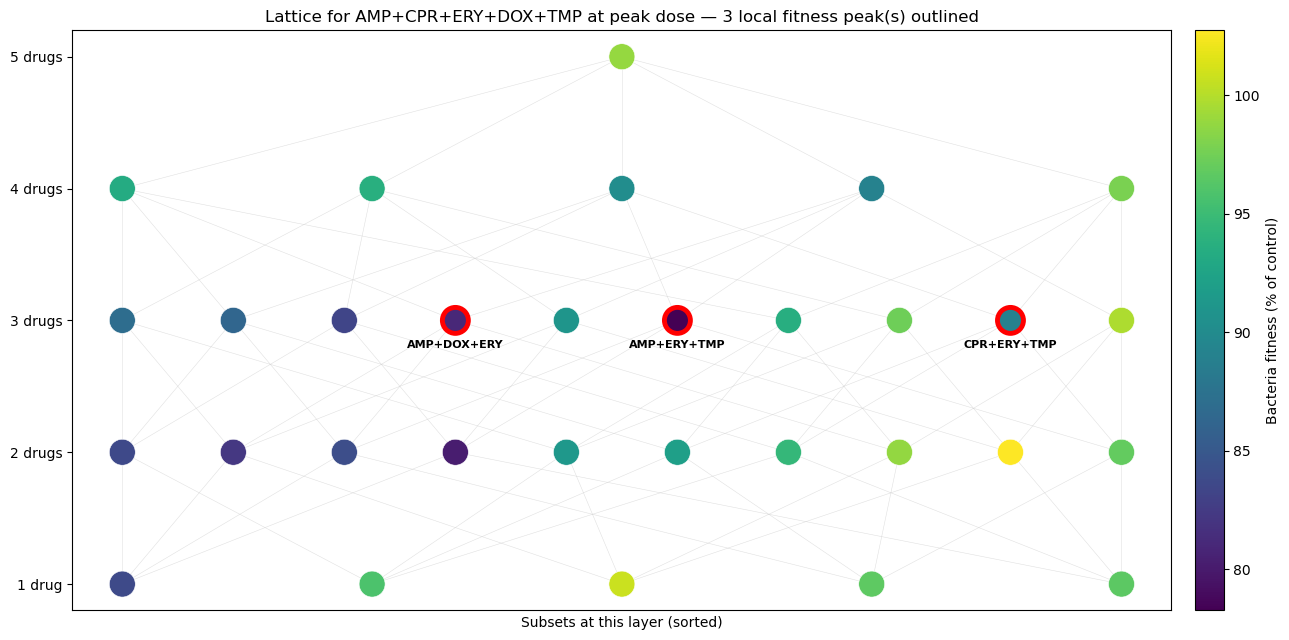

In [28]:
fit_map = {s: f for s, f in slice_nodes}
peaks = set()
for s, fs in slice_nodes:
    nbrs = [fit_map[t] for t in fit_map if len(s.symmetric_difference(t)) == 1]
    if nbrs and all(ft >= fs + 1e-9 for ft in nbrs):
        peaks.add(s)

by_size_local = {}
for s, _ in slice_nodes:
    by_size_local.setdefault(len(s), []).append(s)
pos = {}
for sz, items in by_size_local.items():
    items_sorted = sorted(items, key=lambda s: tuple(sorted(s)))
    n = len(items_sorted)
    for i, s in enumerate(items_sorted):
        x = (i - (n - 1) / 2) / max(n - 1, 1) if n > 1 else 0.0
        pos[s] = (x, sz)

xs = np.array([pos[s][0] for s, _ in slice_nodes])
ys = np.array([pos[s][1] for s, _ in slice_nodes])
fits = np.array([f for _, f in slice_nodes])

fig, ax = plt.subplots(figsize=(13, 6.5))
for s, _ in slice_nodes:
    for t, _ in slice_nodes:
        if t.issuperset(s) and len(t) - len(s) == 1:
            ax.plot([pos[s][0], pos[t][0]], [pos[s][1], pos[t][1]],
                    color="#cccccc", lw=0.4, alpha=0.6, zorder=1)

edge_widths = [3.5 if s in peaks else 0.4 for s, _ in slice_nodes]
edge_colors = ["red" if s in peaks else "white" for s, _ in slice_nodes]
sc = ax.scatter(xs, ys, c=fits, cmap="viridis", s=350,
                edgecolors=edge_colors, linewidths=edge_widths, zorder=2)
for s, _ in slice_nodes:
    if s in peaks:
        ax.text(pos[s][0], pos[s][1] - 0.15, "+".join(sorted(s)),
                fontsize=8, ha="center", va="top", color="black", zorder=3, weight = 'bold')
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Bacteria fitness (% of control)")
ax.set_yticks(sorted(by_size_local))
ax.set_yticklabels([f"{k} drug{'s' if k != 1 else ''}" for k in sorted(by_size_local)])
ax.set_xticks([])
ax.set_xlabel("Subsets at this layer (sorted)")
ax.set_title(f"Lattice for {'+'.join(focal)} at peak dose — "
             f"{len(peaks)} local fitness peak(s) outlined")
plt.tight_layout()
plt.show()

ax.figure.savefig('part1_lattice_example.png', dpi=300)

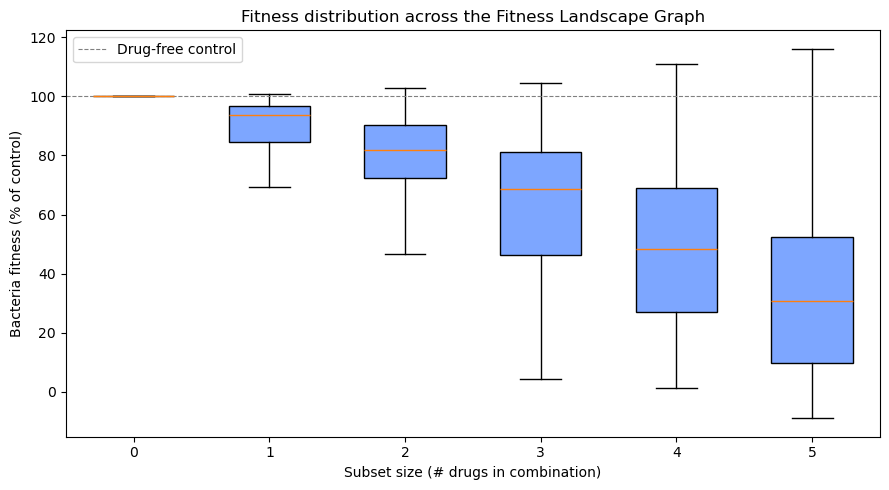

In [27]:
with open("G.pkl", "rb") as f:
    G = pickle.load(f)

fit_by_size = defaultdict(list)
for _, data in G.nodes(data=True):
    fit_by_size[data["size"]].append(data["fitness"])

sizes = sorted(fit_by_size)
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([fit_by_size[s] for s in sizes], positions=sizes,
                widths=0.6, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#7da6ff")
ax.axhline(100, color="gray", ls="--", lw=0.8, label="Drug-free control")
ax.set_xticks(sizes)
ax.set_xlabel("Subset size (# drugs in combination)")
ax.set_ylabel("Bacteria fitness (% of control)")
ax.set_title("Fitness distribution across the Fitness Landscape Graph")
ax.legend()
plt.tight_layout()
plt.show()

ax.figure.savefig('part1_boxplot.png', dpi=300)

Polish basin bar chart from Part 2

Polish MOA enrichment heatmap from Part 3

## Writeup integration

Markdown narrative tying basins, MOA, and topology together